#### TYPEDICT:::

In [1]:
person = {"name":"surya","age":28,"company":"newgen software"}

In [2]:
person['maritalStatus']='Not known'
person['education']=12345
person['designation']='T34m L34434der'


In [3]:
person

{'name': 'surya',
 'age': 28,
 'company': 'newgen software',
 'maritalStatus': 'Not known',
 'education': 12345,
 'designation': 'T34m L34434der'}

From above, we can see that, there are no restrictions for data to be inserted inside a dictionary. Now **Type Dict** doesn't allow this. It is like setting the request tags of an API with a particular type. This will restrict the data to be inserted inside a dictionary to a particular type. For example, if we set the type of a dictionary to `int`, then only integer values can be inserted into that dictionary. Any attempt to insert a value of a different type will result in an error.

State will be maintanied in a Type Dict, and it will only have two keys, i,e. "Question" and "Answer" of type `str`. This means that the dictionary can only hold string values for both the "Question" and "Answer" keys. If you try to insert a value of a different type, such as an integer or a list, it will raise a type error.

In [6]:
from typing import TypedDict

In [8]:
class State(TypedDict):
    question:str
    answer:str

In [9]:
State(question=12213,answer=213)

{'question': 12213, 'answer': 213}

### Build a basic flow in LangGraph

Start -> Analyse -> respond -> End

In [10]:
%pip install langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from dotenv import load_dotenv
import os
from openai import OpenAI
from langgraph.graph import StateGraph, START,END
from IPython.display import display,Image

In [13]:
load_dotenv()
grokAPIKey = os.getenv("GroqAPIKey")


In [14]:
client = OpenAI(api_key=grokAPIKey,base_url="https://api.groq.com/openai/v1")

In [17]:
def speakWithLLM(prompt):
    message = [{
        "role":"system",
        "content":"You are an useful assistant"
    },
    {
        "role":"user",
        "content":prompt

    }]

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=message,
        temperature=0.2
    )

    return response.choices[0].message.content

In [18]:
print(speakWithLLM("Which model are you using?"))

I'm an AI designed by Meta AI, and I'm using a combination of natural language processing (NLP) and machine learning algorithms to understand and respond to your questions. My primary model is based on a transformer architecture, which allows me to process and generate human-like language. I'm constantly learning and improving my responses based on the conversations I have with users like you.


In [20]:
print(speakWithLLM("One beautyful place of France?"))

One beautiful place in France is the French Riviera, also known as the Côte d'Azur. It's a stunning stretch of coastline along the Mediterranean Sea, known for its crystal-clear waters, picturesque villages, and breathtaking scenery.

Some popular destinations in the French Riviera include:

1. **Saint-Tropez**: A charming fishing village turned luxury resort town, famous for its beautiful beaches, yachts, and vibrant nightlife.
2. **Cannes**: A glamorous city known for its film festival, luxurious hotels, and stunning beaches.
3. **Monaco**: A tiny principality with a beautiful casino, stunning harbor, and breathtaking views of the Mediterranean.
4. **Nice**: A vibrant city with a rich history, beautiful beaches, and a famous promenade, the Promenade des Anglais.
5. **Èze**: A medieval village perched on a hilltop, offering breathtaking views of the Mediterranean and a charming atmosphere.

The French Riviera is a perfect destination for those who love the sea, sunshine, and a touch o

## A simple Graph model

### State class

In [22]:
class InputState:
    name:str
    greeting:str
    output:str

### Creating Node

In [45]:
## NOde is nothing but a python function

def greeting(state):
    '''Creating a greeting node with name'''
    name = state['name']
    greeting = f"Hello {name}, Welcome to simple Langgraph build"
    return {'greetings':greeting}

def makeUppercase(state):
    result = state['name'].upper()
    print(f"result:  {result}")
    return{"output":result}




### Graph Creation - Nodes

In [46]:
graph = StateGraph(InputState)

graph.add_node("greeting",greeting)
graph.add_node("makeUppercase",makeUppercase)

### Graph creation - Edges

In [47]:
graph.add_edge(START,"greeting")
graph.add_edge("greeting","makeUppercase")
graph.add_edge("makeUppercase",END)


In [48]:
simpleGraph = graph.compile()

print("Graph is built")

Graph is built


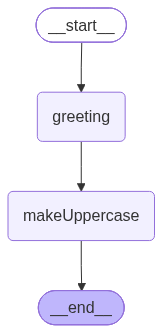

In [43]:
display(Image(simpleGraph.get_graph().draw_mermaid_png()))

In [49]:
simpleGraph.invoke({"name":"Veena"})

result:  VEENA


{'name': 'Veena', 'output': 'VEENA'}